# **Lab Assignment-1**

## 1. **Binary Classification:** Implement Perceptron and Logistic Regression from scratch for binary classification (Use pytorch, numpy, etc. but not built-in implementations from sklearn.
    a. Load the train and test datasets given as train bin.csv and test bin.csv. Do appropriate preprocessing steps.
    b. Implement perceptron and logistic regression models and train them on the given dataset. Experiment with different learning rates (e.g., 0.01, 0.1) and iterations (e.g., 50, 100).
    c. Plot the decision boundary of the best models (one from each classifier algorithm) on training data.

### Importing the necessary modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Data Extraction from CSV files

In [2]:
df_train = pd.read_csv("train_bin.csv")
df_test = pd.read_csv("test_bin.csv")

In [3]:
columns = ['feature_1', 'feature_2']
X_train = df_train[columns]
y_train = df_train['label']
X_test = df_test[columns]
y_test = df_test['label']

In [4]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

### Implementing the Models for Binary Classification

In [5]:
class Perceptron:
    def __init__(self, lr = 0, epochs = 0):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.epochs):
            for j in range(n_samples):
                z = np.dot(X[j], self.w) + self.b
                y_pred = 1 if z>=0 else 0
                update = self.lr * (y[j]-y_pred)
                self.w += update * X[j]
                self.b += update

    def predict(self, X):
        return np.array([1 if np.dot(x,self.w) + self.b >=0 else 0 for x in X])        

    def classification_report(self, y_pred, y_test):
        count = 0
        for i in range(len(y_test)):
            if y_test[i] == y_pred[i]:
                count+=1
        accuracy = (count*100)/len(y_test)
        
        tp, tn, fp, fn = 0,0,0,0
        for i in range(len(y_test)):
            if y_pred[i] == 1 and y_test[i] == 1:
                tp+=1
            if y_pred[i] == 0 and y_test[i] == 0:
                tn+=1
            if y_pred[i] == 1 and y_test[i] == 0:
                fp+=1
            if y_pred[i] == 0 and y_test[i] == 1:
                fn+=1    
    
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1_score = (2*tp + fn + fp)/(2*tp)

        print("Classification Report:")
        print("Accuracy =", accuracy)
        print("Precision =", precision)
        print("Recall =", recall)
        print("F1 score =", f1_score)

In [6]:
class LogisticRegression:
    def __init__(self, lr=0, epochs=0):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1/(1+np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.epochs):
            for j in range(n_samples):
                z = np.dot(X[j], self.w) + self.b
                y_pred =self.sigmoid(z)
                error = y_pred - y[j]
                self.w -= self.lr * error * X[j]
                self.b -= self.lr * error

    def predict(self, X):
        probs = self.sigmoid(np.dot(X, self.w)+self.b)
        return (probs >= 0.5).astype(int)

    def classification_report(self, y_pred, y_test):
        count = 0
        for i in range(len(y_test)):
            if y_test[i] == y_pred[i]:
                count+=1
        accuracy = (count*100)/len(y_test)

        tp, tn, fp, fn = 0,0,0,0        
        for i in range(len(y_test)):
            if y_pred[i] == 1 and y_test[i] == 1:
                tp+=1
            if y_pred[i] == 0 and y_test[i] == 0:
                tn+=1
            if y_pred[i] == 1 and y_test[i] == 0:
                fp+=1
            if y_pred[i] == 0 and y_test[i] == 1:
                fn+=1    

        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1_score = (2*tp + fn + fp)/(2*tp)

        print("Classification Report:")
        print("Accuracy =", accuracy)
        print("Precision =", precision)
        print("Recall =", recall)
        print("F1 score =", f1_score)


### Training the Perceptron model for different parameters

In [7]:
p_model_1 = Perceptron(0.01, 50)
line = p_model_1.fit(X_train, y_train)

In [8]:
p_model_2 = Perceptron(0.01, 100)
p_model_2.fit(X_train, y_train)

In [9]:
p_model_3 = Perceptron(0.1, 50)
p_model_3.fit(X_train, y_train)

In [10]:
p_model_4 = Perceptron(0.1, 100)
p_model_4.fit(X_train, y_train)

### Training the LR model for different parameters

In [11]:
lr_model_1 = LogisticRegression(0.01, 50)
lr_model_1.fit(X_train, y_train)

In [12]:
lr_model_2 = LogisticRegression(0.01, 100)
lr_model_2.fit(X_train, y_train)

In [13]:
lr_model_3 = LogisticRegression(0.1, 50)
lr_model_3.fit(X_train, y_train)

In [14]:
lr_model_4 = LogisticRegression(0.1, 100)
lr_model_4.fit(X_train, y_train)

### PLotting the decision boundary for the best models from each algorithm

/tmp/ipykernel_17486/485044154.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


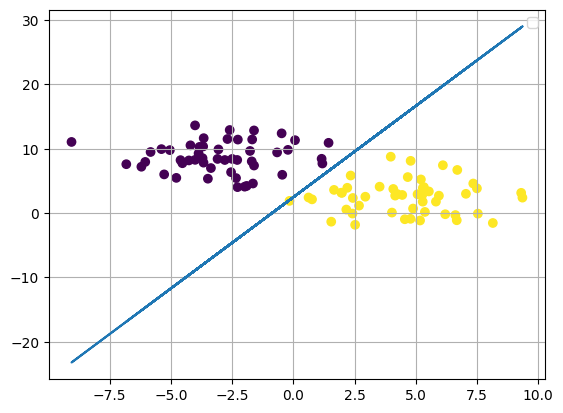

In [15]:
w1,w2 = p_model_1.w

plt.scatter(X_train[:,0], X_train[:,1], c = y_train)
plt.plot(X_train[:,0], (-w1*X_train[:,0]-p_model_1.b)/w2)

plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_17486/1862676379.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


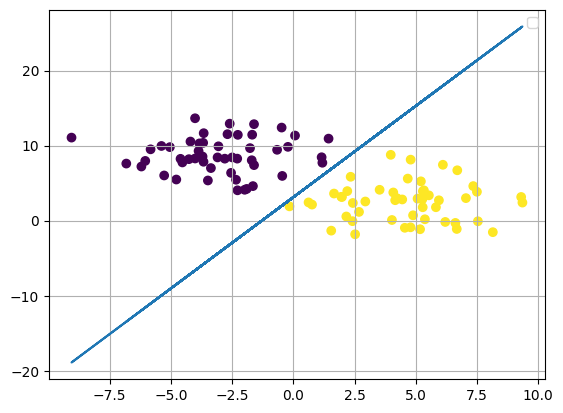

In [16]:
w1,w2 = lr_model_3.w

plt.scatter(X_train[:,0], X_train[:,1], c = y_train)
plt.plot(X_train[:,0], (-w1*X_train[:,0]-lr_model_3.b)/w2)

plt.legend()
plt.grid(True)
plt.show()

## 2. **Evaluation and Comparison:** Make observations regarding the learned decision boundary from the plots generated, and evaluate the models on the test set.
    a. Which model would be more generalizable to unseen data? What are the possible reasons?
    b. Evaluate the models from question 1 on the test set. Report the accuracy and other classification metrics. Compare the performance of both models.

### Logistic Regression would be more generalizable to unseen data since Perceptron wont converge for non-linearly seperable data.

### Classification Report for Perceptron models:

In [17]:
y_pred_1 = p_model_1.predict(X_test)
p_model_1.classification_report(y_pred_1, y_test)

Classification Report:
Accuracy = 95.0
Precision = 0.9830508474576272
Recall = 0.9354838709677419
F1 score = 1.043103448275862


In [18]:
y_pred_2 = p_model_2.predict(X_test)
p_model_2.classification_report(y_pred_2, y_test)

Classification Report:
Accuracy = 95.0
Precision = 0.9830508474576272
Recall = 0.9354838709677419
F1 score = 1.043103448275862


In [19]:
y_pred_3 = p_model_3.predict(X_test)
p_model_3.classification_report(y_pred_3, y_test)

Classification Report:
Accuracy = 95.0
Precision = 0.9830508474576272
Recall = 0.9354838709677419
F1 score = 1.043103448275862


In [20]:
y_pred_4 = p_model_4.predict(X_test)
p_model_4.classification_report(y_pred_4, y_test)

Classification Report:
Accuracy = 95.0
Precision = 0.9830508474576272
Recall = 0.9354838709677419
F1 score = 1.043103448275862


### Classification Report for LR models:

In [21]:
ylr_pred_1 = lr_model_1.predict(X_test)
lr_model_1.classification_report(ylr_pred_1, y_test)

Classification Report:
Accuracy = 95.0
Precision = 0.9830508474576272
Recall = 0.9354838709677419
F1 score = 1.043103448275862


In [22]:
ylr_pred_2 = lr_model_2.predict(X_test)
lr_model_2.classification_report(ylr_pred_2, y_test)

Classification Report:
Accuracy = 95.0
Precision = 0.9830508474576272
Recall = 0.9354838709677419
F1 score = 1.043103448275862


In [23]:
ylr_pred_3 = lr_model_3.predict(X_test)
lr_model_3.classification_report(ylr_pred_3, y_test)

Classification Report:
Accuracy = 97.0
Precision = 0.9836065573770492
Recall = 0.967741935483871
F1 score = 1.025


In [24]:
ylr_pred_4 = lr_model_4.predict(X_test)
lr_model_4.classification_report(ylr_pred_4, y_test)

Classification Report:
Accuracy = 97.0
Precision = 0.9836065573770492
Recall = 0.967741935483871
F1 score = 1.025


## 3. **Multi-class Classification:** Modify your implementations to handle multi-class classification.
    a. Load the train and test datasets given as train multi.csv and test multi.csv. Do appropriate preprocessing steps.
    b. Repeat the steps in question 1: Experiments with different setups, plot decision boundary of the best models.
    c. Evaluate the model on test set and compare their performances.

In [25]:
data_train = pd.read_csv("train_multi.csv")
data_test = pd.read_csv("test_multi.csv")

In [26]:
X1_train = data_train[columns]
y1_train = data_train['label']
X1_test = data_test[columns]
y1_test = data_test['label']

In [27]:
X1_train = np.array(X1_train)
y1_train = np.array(y1_train)
X1_test = np.array(X1_test)
y1_test = np.array(y1_test)

### Implementing the Models for MultiClass Classification

In [28]:
class Perceptron:
    def __init__(self, lr = 0, epochs = 0):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        uniq = np.unique(y)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.epochs):
            for j in range(n_samples):
                z = np.dot(X[j], self.w) + self.b
                y_pred = 1 if z>=0 else 0
                update = self.lr * (y[j]-y_pred)
                self.w += update * X[j]
                self.b += update

    def predict(self, X):
        return np.array([1 if np.dot(x,self.w) + self.b >=0 else 0 for x in X])        

    def classification_report(self, y_pred, y_test):
        count = 0
        for i in range(len(y_test)):
            if y_test[i] == y_pred[i]:
                count+=1
        accuracy = (count*100)/len(y_test)
        
        tp, tn, fp, fn = 0,0,0,0
        for i in range(len(y_test)):
            if y_pred[i] == 1 and y_test[i] == 1:
                tp+=1
            if y_pred[i] == 0 and y_test[i] == 0:
                tn+=1
            if y_pred[i] == 1 and y_test[i] == 0:
                fp+=1
            if y_pred[i] == 0 and y_test[i] == 1:
                fn+=1    
    
        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1_score = (2*tp + fn + fp)/(2*tp)

        print("Classification Report:")
        print("Accuracy =", accuracy)
        print("Precision =", precision)
        print("Recall =", recall)
        print("F1 score =", f1_score)

In [29]:
class LogisticRegression:
    def __init__(self, lr=0, epochs=0):
        self.lr = lr
        self.epochs = epochs

    def sigmoid(self, z):
        return 1/(1+np.exp(-z))
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.epochs):
            for j in range(n_samples):
                z = np.dot(X[j], self.w) + self.b
                y_pred =self.sigmoid(z)
                error = y_pred - y[j]
                self.w -= self.lr * error * X[j]
                self.b -= self.lr * error

    def predict(self, X):
        probs = self.sigmoid(np.dot(X, self.w)+self.b)
        return (probs >= 0.5).astype(int)

    def classification_report(self, y_pred, y_test):
        count = 0
        for i in range(len(y_test)):
            if y_test[i] == y_pred[i]:
                count+=1
        accuracy = (count*100)/len(y_test)

        tp, tn, fp, fn = 0,0,0,0        
        for i in range(len(y_test)):
            if y_pred[i] == 1 and y_test[i] == 1:
                tp+=1
            if y_pred[i] == 0 and y_test[i] == 0:
                tn+=1
          PLotting  if y_pred[i] == 1 and y_test[i] == 0:
                fp+=1
            if y_pred[i] == 0 and y_test[i] == 1:
                fn+=1    

        precision = tp/(tp+fp)
        recall = tp/(tp+fn)
        f1_score = (2*tp + fn + fp)/(2*tp)

        print("Classification Report:")
        print("Accuracy =", accuracy)
        print("Precision =", precision)
        print("Recall =", recall)
        print("F1 score =", f1_score)

### Training the Perceptron model for different parameters

In [38]:
uniq = np.unique(y1_train)
y_train_comb = []
for i in uniq:
    temp = []
    for j in y1_train:
        if j==i:
            temp.append(1)
        else:
            temp.append(0)
    y_train_comb.append(temp)

[[0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  1,
  0,
  0,
  1],
 [0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0]

In [41]:
y_test_comb = []
for i in uniq:
    temp = []
    for j in y1_test:
        if j==i:
            temp.append(1)
        else:
            temp.append(0)
    y_test_comb.append(temp)

In [42]:
y_train_0 = np.array(y_train_comb[0])
y_train_1 = np.array(y_train_comb[1])
y_train_2 = np.array(y_train_comb[2])

In [43]:
y_test_0 = np.array(y_test_comb[0])
y_test_1 = np.array(y_test_comb[1])
y_test_2 = np.array(y_test_comb[2])

In [ ]:
y_pred_comb = []
models = []
for i in uniq:
    temp = []
    pm1 = Perceptron(lr = 0.01, epoch = 100)
    pm1

### Training the LR model for different parameters

### Plotting the decision boundary for the best models from each algorithm